# Week 5 – Advanced Model Training
### Cardiovascular Disease Risk Prediction



## 1. Import Libraries & Load Cleaned Dataset

In [5]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [6]:
df = pd.read_csv("cardio_cleaned.csv")
print("Shape of cleaned dataset:", df.shape)
df.head()

Shape of cleaned dataset: (68573, 14)


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure
0,2,168,62.0,110,80,1,1,0,0,1,0,50.391781,21.967120,30
1,1,156,85.0,140,90,3,1,0,0,1,1,55.419178,34.927679,50
2,1,165,64.0,130,70,3,1,0,0,0,1,51.663014,23.507805,60
3,2,169,82.0,150,100,1,1,0,0,1,1,48.282192,28.710479,50
4,1,156,56.0,100,60,1,1,0,0,0,0,47.873973,23.011177,40


In [7]:
continuous_cols = ['age_years', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo', 'pulse_pressure']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[continuous_cols] = scaler.fit_transform(df[continuous_cols])

X = df_scaled.drop(columns=['cardio'])
y = df_scaled['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (54858, 13)  X_test: (13715, 13)


## 2. Candidate Models



In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42),
}

for name, mdl in models.items():
    print(name, '->', mdl)

Logistic Regression -> LogisticRegression(max_iter=1000, random_state=42)
K-Nearest Neighbors -> KNeighborsClassifier(n_neighbors=15)
Random Forest -> RandomForestClassifier(max_depth=8, n_estimators=200, n_jobs=-1,
                       random_state=42)
Gradient Boosting -> GradientBoostingClassifier(n_estimators=150, random_state=42)


## 3. Cross-Validation



In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc']

cv_summary = []
cv_raw = {}

for name, mdl in models.items():
    t0 = time.time()
    res = cross_validate(mdl, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - t0
    cv_raw[name] = res
    cv_summary.append({
        'Model': name,
        'CV Accuracy (mean)': res['test_accuracy'].mean(),
        'CV Accuracy (std)': res['test_accuracy'].std(),
        'CV F1 (mean)': res['test_f1'].mean(),
        'CV ROC-AUC (mean)': res['test_roc_auc'].mean(),
        'Fit Time (s)': elapsed,
    })
    print(f"{name} done in {elapsed:.1f}s")

cv_results = pd.DataFrame(cv_summary).set_index('Model').round(4).sort_values('CV ROC-AUC (mean)', ascending=False)
cv_results

Logistic Regression done in 2.0s
K-Nearest Neighbors done in 11.8s
Random Forest done in 12.3s
Gradient Boosting done in 19.4s


,CV Accuracy (mean),CV Accuracy (std),CV F1 (mean),CV ROC-AUC (mean),Fit Time (s)
Model,,,,,
Gradient Boosting,0.7356,0.0039,0.7211,0.8013,19.3517
Random Forest,0.7330,0.0044,0.7092,0.8002,12.2863
Logistic Regression,0.7278,0.0041,0.7082,0.7917,2.0479
K-Nearest Neighbors,0.7240,0.0035,0.7111,0.7813,11.8216


C:\Users\lakht\AppData\Local\Temp\ipykernel_15916\1704984132.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=list(models.keys()))


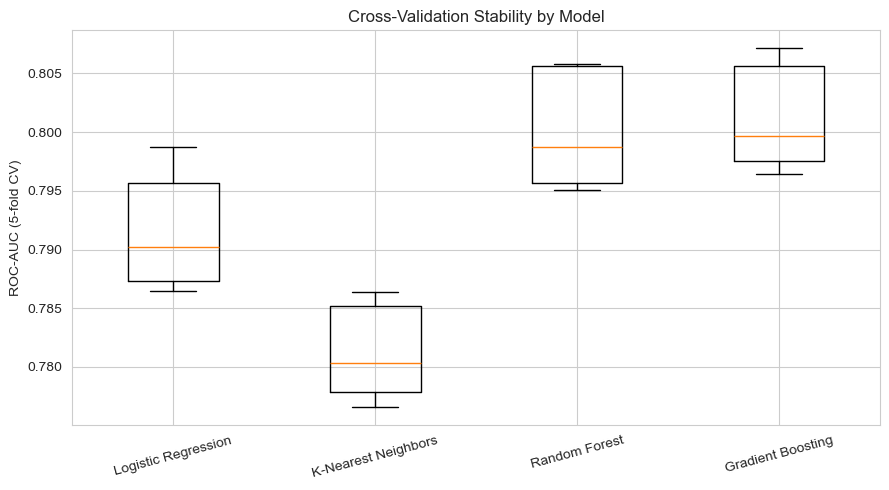

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
box_data = [cv_raw[name]['test_roc_auc'] for name in models]
ax.boxplot(box_data, labels=list(models.keys()))
ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_title('Cross-Validation Stability by Model')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning (Grid Search)



In [11]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1],
}

tuning_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=tuning_cv,
    scoring='roc_auc',
    n_jobs=-1,
)

t0 = time.time()
grid_search.fit(X_train, y_train)
print(f"Grid search took {time.time() - t0:.1f}s")

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 4))

Grid search took 93.1s
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV ROC-AUC: 0.8012


In [12]:
cv_grid_results = pd.DataFrame(grid_search.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(10).reset_index(drop=True)

cv_grid_results

,params,mean_test_score,std_test_score,rank_test_score
0,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.801214,0.005887,1
1,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.801070,0.005770,2
2,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.800874,0.005955,3
3,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",0.800839,0.005792,4
4,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",0.800706,0.005796,5
5,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.800594,0.005676,6
6,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.800167,0.005942,7
7,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.800048,0.005947,8
8,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.799382,0.005747,9
9,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.799333,0.005679,10


## 5. Compare Tuned Model vs. Baseline on the Held-Out Test Set



In [13]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)
y_proba_base = baseline_model.predict_proba(X_test)[:, 1]

final_comparison = pd.DataFrame([
    {
        'Model': 'Logistic Regression (baseline)',
        'Train Accuracy': accuracy_score(y_train, baseline_model.predict(X_train)),
        'Test Accuracy': accuracy_score(y_test, y_pred_base),
        'Test F1': f1_score(y_test, y_pred_base),
        'Test ROC-AUC': roc_auc_score(y_test, y_proba_base),
    },
    {
        'Model': f'Tuned Gradient Boosting {grid_search.best_params_}',
        'Train Accuracy': accuracy_score(y_train, best_model.predict(X_train)),
        'Test Accuracy': accuracy_score(y_test, y_pred_best),
        'Test F1': f1_score(y_test, y_pred_best),
        'Test ROC-AUC': roc_auc_score(y_test, y_proba_best),
    },
]).set_index('Model').round(4)

final_comparison

,Train Accuracy,Test Accuracy,Test F1,Test ROC-AUC
Model,,,,
Logistic Regression (baseline),0.7277,0.7258,0.7053,0.7894
"Tuned Gradient Boosting {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}",0.7391,0.7326,0.7187,0.7987


In [14]:
print("Tuned Gradient Boosting — Classification Report")
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

Tuned Gradient Boosting — Classification Report
              precision    recall  f1-score   support

           0       0.72      0.77      0.75      6929
           1       0.75      0.69      0.72      6786

    accuracy                           0.73     13715
   macro avg       0.73      0.73      0.73     13715
weighted avg       0.73      0.73      0.73     13715

[[5363 1566]
 [2101 4685]]


## 6. Feature Importance (Tuned Gradient Boosting)

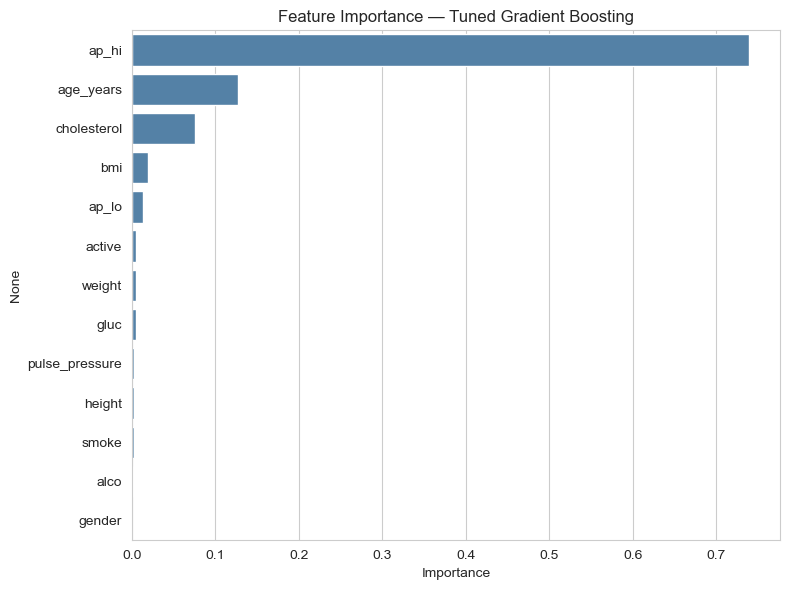

ap_hi             0.739722
age_years         0.127345
cholesterol       0.075766
bmi               0.019340
ap_lo             0.013203
active            0.005271
weight            0.005051
gluc              0.004634
pulse_pressure    0.002836
height            0.002716
smoke             0.002265
alco              0.001619
gender            0.000232
dtype: float64

In [15]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color='steelblue')
plt.title('Feature Importance — Tuned Gradient Boosting')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances